In [5]:
"""
Phase 1: MLM Pre-training for Equation Encoder
================================================
Train a Transformer encoder to understand equation structure
by predicting masked tokens in prefix expressions.

Input:  ADD SUB x1 [MASK] x2 x1 MUL [MASK] <C_0> x2
Target: ADD SUB x1 POW    x2 x1 MUL SUB    <C_0> x2

After pre-training, the encoder understands:
  - What operators are valid in what positions
  - How variables relate to operators
  - Where constants appear in expression trees
  - The prefix notation tree structure

Phase 2 (separate file): Freeze/finetune this encoder with JEPA + point encoder.
"""

import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

# ==========================================
# 1. VOCABULARY
# ==========================================

SPECIAL_TOKENS = ["[PAD]", "[MASK]", "[UNK]"]

KNOWN_TOKENS = [
    # binary ops
    "ADD", "SUB", "MUL", "DIV", "POW",
    # unary ops
    "sin", "cos", "tan", "exp", "sqrt", "log", "NEG", "tanh",
    "arcsin", "arccos", "arctan",
    # variables
    "x1", "x2", "x3",
    # special constants
    "pi", "e",
    # masked constants
    "<C_0>", "<C_1>", "<C_2>", "<C_3>",
]


def build_vocab(df, expr_col="expression_prefix_masked"):
    """Build vocab from known tokens + scan data for any extras."""
    vocab = {}
    for t in SPECIAL_TOKENS + KNOWN_TOKENS:
        vocab[t] = len(vocab)

    # scan for any unknown tokens in data
    extras = set()
    for expr in df[expr_col].dropna():
        for tok in str(expr).strip().split():
            if tok not in vocab:
                extras.add(tok)

    for t in sorted(extras):
        vocab[t] = len(vocab)

    if extras:
        print(f"  Extra tokens found in data: {extras}")

    print(f"  Vocab size: {len(vocab)}")
    print(f"  Tokens: {list(vocab.keys())}")
    return vocab


# ==========================================
# 2. MLM DATASET
# ==========================================

class MLMDataset(Dataset):
    """
    Loads expressions, applies random masking for MLM.

    Masking strategy (BERT-style):
      - 15% of tokens selected for prediction
      - Of those: 80% → [MASK], 10% → random token, 10% → keep original
      - [PAD] tokens are never masked
      - Loss computed only on masked positions
    """

    def __init__(self, csv_path, vocab, expr_col="expression_prefix_masked",
                 max_len=40, mask_prob=0.15):
        print(f"Loading expressions from {csv_path} ...")
        df = pd.read_csv(csv_path)

        self.vocab = vocab
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.pad_id = vocab["[PAD]"]
        self.mask_id = vocab["[MASK]"]
        self.vocab_size = len(vocab)

        # tokenize all expressions
        self.sequences = []
        self.lengths = []

        skipped = 0
        for expr in tqdm(df[expr_col].values, desc="Tokenizing"):
            if not isinstance(expr, str) or expr.strip() == "":
                skipped += 1
                continue
            tokens = expr.strip().split()
            if len(tokens) < 2:
                skipped += 1
                continue
            ids = [vocab.get(t, vocab["[UNK]"]) for t in tokens[:max_len]]
            self.sequences.append(ids)
            self.lengths.append(len(ids))

        print(f"  Loaded {len(self.sequences)} expressions (skipped {skipped})")
        print(f"  Avg length: {np.mean(self.lengths):.1f} tokens")
        print(f"  Max length: {max(self.lengths)} tokens")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        ids = self.sequences[idx]
        seq_len = len(ids)

        # pad to max_len
        input_ids = [self.pad_id] * self.max_len
        input_ids[:seq_len] = ids

        # create labels: -100 = ignore in loss (unmasked + padding)
        labels = [-100] * self.max_len

        # apply masking
        for i in range(seq_len):
            if random.random() < self.mask_prob:
                labels[i] = input_ids[i]  # target = original token

                r = random.random()
                if r < 0.8:
                    input_ids[i] = self.mask_id            # 80% → [MASK]
                elif r < 0.9:
                    input_ids[i] = random.randint(3, self.vocab_size - 1)  # 10% → random (skip special)
                # else 10% → keep original (input_ids[i] unchanged)

        # attention mask
        attn_mask = [True] * seq_len + [False] * (self.max_len - seq_len)

        return (torch.tensor(input_ids, dtype=torch.long),
                torch.tensor(labels, dtype=torch.long),
                torch.tensor(attn_mask, dtype=torch.bool))


# ==========================================
# 3. TRANSFORMER ENCODER + MLM HEAD
# ==========================================

class EquationTransformer(nn.Module):
    """
    Transformer encoder for equation prefix expressions.

    Architecture:
      token embedding (vocab → 128) + positional embedding (max_len → 128)
        → 4-layer Transformer with 4 heads
        → 128-dim contextual representation per token

    Deeper than the JEPA version (4 layers vs 2) because:
      - MLM needs strong bidirectional context understanding
      - No cross-modal alignment to destabilize training
      - Pre-training can afford more capacity — we'll freeze/reduce for Phase 2

    MLM head:
      hidden → LayerNorm → Linear → vocab_size (predict masked tokens)
    """

    def __init__(self, vocab_size, max_len=40, d_model=256,
                 n_layers=4, n_heads=8, d_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        # embeddings
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.embed_norm = nn.LayerNorm(d_model)
        self.embed_drop = nn.Dropout(dropout)

        # transformer encoder
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_ff, dropout=dropout,
                activation="gelu", batch_first=True, norm_first=True),
            num_layers=n_layers)

        # MLM prediction head
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size),
        )

    def get_encoder_output(self, token_ids, mask=None):
        """Get contextual representations (used in Phase 2)."""
        B, L = token_ids.shape
        pos = torch.arange(L, device=token_ids.device).unsqueeze(0)
        h = self.token_embed(token_ids) + self.pos_embed(pos)
        h = self.embed_drop(self.embed_norm(h))
        kp = ~mask if mask is not None else None
        h = self.transformer(h, src_key_padding_mask=kp)
        return h  # (B, L, d_model)

    def forward(self, token_ids, mask=None):
        """Full forward with MLM logits."""
        h = self.get_encoder_output(token_ids, mask)    # (B, L, D)
        logits = self.mlm_head(h)                        # (B, L, vocab_size)
        return logits


# ==========================================
# 4. TRAINING
# ==========================================

def train_mlm(csv_file, epochs=200, batch_size=512, lr=3e-3,
              expr_col="expression_prefix_masked"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ── Data: split DataFrame FIRST, then create separate datasets ──
    df = pd.read_csv(csv_file)
    vocab = build_vocab(df, expr_col)

    # shuffle and split at DataFrame level — completely separate equations
    df_valid = df[df[expr_col].notna() & (df[expr_col].str.strip() != "")].copy()
    df_valid = df_valid[df_valid[expr_col].apply(lambda x: len(str(x).strip().split()) >= 2)]
    df_valid = df_valid.sample(frac=1, random_state=42).reset_index(drop=True)

    n_train = int(0.9 * len(df_valid))
    df_train = df_valid.iloc[:n_train].reset_index(drop=True)
    df_val   = df_valid.iloc[n_train:].reset_index(drop=True)

    print(f"  Train equations: {len(df_train)} | Val equations: {len(df_val)} (completely separate)")

    # save split CSVs so train/val are separate
    train_csv = csv_file.replace(".csv", "_train_split.csv")
    val_csv   = csv_file.replace(".csv", "_val_split.csv")
    df_train.to_csv(train_csv, index=False)
    df_val.to_csv(val_csv, index=False)

    train_ds = MLMDataset(train_csv, vocab, expr_col)
    val_ds   = MLMDataset(val_csv, vocab, expr_col)

    # T4 safe: batch 512, num_workers=2, pin_memory
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               pin_memory=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             pin_memory=True, num_workers=2)

    # ── Model: bigger for 37-token vocab ──
    model = EquationTransformer(
        vocab_size=len(vocab), max_len=40,
        d_model=256, n_layers=4, n_heads=8, d_ff=512, dropout=0.1
    ).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nMLM Pre-training | {device}")
    print(f"  Params: {n_params:,}")
    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Batch: {batch_size}")
    print(f"  Epochs: {epochs} | LR: {lr}")
    print(f"  AMP: {device.type == 'cuda'} | Label smoothing: 0.1\n")

    # ── Optimizer ──
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias",
                "embed_norm.weight", "embed_norm.bias"}
    param_groups = [
        {"params": [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)],
         "weight_decay": 0.05},
        {"params": [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer = torch.optim.AdamW(param_groups, lr=lr, betas=(0.9, 0.98), eps=1e-6)

    # ── Scheduler: cosine with 10% warmup, proper step count ──
    steps_per_epoch = len(train_loader)
    total_steps = epochs * steps_per_epoch
    warmup_steps = int(0.1 * total_steps)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return max(0.01, 0.5 * (1 + math.cos(math.pi * progress)))  # min 1% of peak LR

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # ── AMP scaler (T4 compatible) ──
    use_amp = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    # ── Label smoothing ──
    criterion = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=0.1)

    best_val_loss = float("inf")
    best_val_acc = 0.0
    global_step = 0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        total_loss, total_correct, total_masked, nb = 0, 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Ep {epoch}/{epochs}")

        for input_ids, labels, attn_mask in pbar:
            input_ids = input_ids.to(device, non_blocking=True)
            labels    = labels.to(device, non_blocking=True)
            attn_mask = attn_mask.to(device, non_blocking=True)

            # AMP forward
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(input_ids, attn_mask)
                loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

            if torch.isnan(loss):
                loss = torch.tensor(0.0, device=device, requires_grad=True)

            # backward + step every batch
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            global_step += 1
            scheduler.step()

            # accuracy on masked tokens
            with torch.no_grad():
                mask_pos = labels != -100
                if mask_pos.any():
                    preds = logits.argmax(dim=-1)
                    correct = (preds[mask_pos] == labels[mask_pos]).sum().item()
                    total_correct += correct
                    total_masked += mask_pos.sum().item()

            total_loss += loss.item(); nb += 1
            acc = total_correct / max(total_masked, 1)
            cur_lr = optimizer.param_groups[0]["lr"]
            pbar.set_postfix({"loss": f"{loss.item():.4f}",
                              "acc": f"{acc:.3f}", "lr": f"{cur_lr:.1e}"})

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_masked, val_nb = 0, 0, 0, 0

        with torch.no_grad():
            for input_ids, labels, attn_mask in val_loader:
                input_ids = input_ids.to(device)
                labels    = labels.to(device)
                attn_mask = attn_mask.to(device)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(input_ids, attn_mask)
                    loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

                mask_pos = labels != -100
                if mask_pos.any():
                    preds = logits.argmax(dim=-1)
                    val_correct += (preds[mask_pos] == labels[mask_pos]).sum().item()
                    val_masked += mask_pos.sum().item()

                val_loss += loss.item(); val_nb += 1

        tl = total_loss / nb
        ta = total_correct / max(total_masked, 1)
        vl = val_loss / val_nb
        va = val_correct / max(val_masked, 1)

        if vl < best_val_loss:
            best_val_loss = vl
            best_val_acc = va
            patience_counter = 0
            # save best
            torch.save({
                "model_state": model.state_dict(),
                "vocab": vocab,
                "d_model": 256, "n_layers": 4, "n_heads": 8, "d_ff": 512,
                "max_len": 40,
                "best_val_loss": best_val_loss,
                "best_val_acc": best_val_acc,
                "epoch": epoch,
            }, "/content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/equation_encoder_mlm.pt")
            print(f"  loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f} ✓ saved")
        else:
            patience_counter += 1
            print(f"  loss={tl:.4f} acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f} (patience {patience_counter}/30)")
            if patience_counter >= 30:
                print(f"\n  Early stopping at epoch {epoch}")
                break

    print(f"\nDone! Best val_loss={best_val_loss:.4f} | val_acc={best_val_acc:.3f}")
    print("Saved: equation_encoder_mlm.pt")
    print("\nPhase 2: Load this checkpoint into the equation encoder for JEPA training.")

    return model, vocab


# ── Quick test: predict masked tokens ──────────────────────

@torch.no_grad()
def test_mlm(checkpoint_path, expressions, device="cuda"):
    """Test the trained MLM by masking and predicting."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    vocab = ckpt["vocab"]
    inv_vocab = {v: k for k, v in vocab.items()}

    model = EquationTransformer(
        vocab_size=len(vocab), max_len=ckpt["max_len"],
        d_model=ckpt["d_model"], n_layers=ckpt["n_layers"],
        n_heads=ckpt["n_heads"], d_ff=ckpt["d_ff"]
    ).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    mask_id = vocab["[MASK]"]
    pad_id = vocab["[PAD]"]

    for expr in expressions:
        tokens = expr.strip().split()
        ids = [vocab.get(t, vocab["[UNK]"]) for t in tokens]

        # mask random positions
        masked_ids = ids.copy()
        masked_positions = []
        for i in range(len(ids)):
            if random.random() < 0.3:  # mask 30% for testing
                masked_positions.append(i)
                masked_ids[i] = mask_id

        # pad
        padded = masked_ids + [pad_id] * (40 - len(masked_ids))
        mask = [True] * len(ids) + [False] * (40 - len(ids))

        input_t = torch.tensor([padded], dtype=torch.long, device=device)
        mask_t = torch.tensor([mask], dtype=torch.bool, device=device)

        logits = model(input_t, mask_t)
        preds = logits[0].argmax(dim=-1)

        # show results
        masked_str = " ".join(inv_vocab.get(t, "?") for t in masked_ids[:len(ids)])
        pred_str = " ".join(inv_vocab.get(preds[i].item(), "?") for i in range(len(ids)))
        original_str = " ".join(tokens)

        print(f"Original: {original_str}")
        print(f"Masked:   {masked_str}")
        print(f"Predicted:{pred_str}")
        correct = sum(1 for i in masked_positions if preds[i].item() == ids[i])
        print(f"Masked {len(masked_positions)} tokens, got {correct} correct\n")


# --- RUN ---
model, vocab = train_mlm(
    csv_file="/content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_final_input_18march.csv",
    epochs=200,
    batch_size=512,
    lr=3e-3,
    expr_col="expression_prefix_masked",
)

  Extra tokens found in data: {'<C_12>', '<C_4>', '<C_6>', '<C_11>', '<C_8>', '<C_5>', '<C_7>', '<C_9>', '<C_10>'}
  Vocab size: 37
  Tokens: ['[PAD]', '[MASK]', '[UNK]', 'ADD', 'SUB', 'MUL', 'DIV', 'POW', 'sin', 'cos', 'tan', 'exp', 'sqrt', 'log', 'NEG', 'tanh', 'arcsin', 'arccos', 'arctan', 'x1', 'x2', 'x3', 'pi', 'e', '<C_0>', '<C_1>', '<C_2>', '<C_3>', '<C_10>', '<C_11>', '<C_12>', '<C_4>', '<C_5>', '<C_6>', '<C_7>', '<C_8>', '<C_9>']
  Train equations: 45000 | Val equations: 5000 (completely separate)
Loading expressions from /content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_final_input_18march_train_split.csv ...


Tokenizing: 100%|██████████| 45000/45000 [00:00<00:00, 282709.55it/s]


  Loaded 45000 expressions (skipped 0)
  Avg length: 15.0 tokens
  Max length: 40 tokens
Loading expressions from /content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_final_input_18march_val_split.csv ...


Tokenizing: 100%|██████████| 5000/5000 [00:00<00:00, 290347.64it/s]
/tmp/ipykernel_6129/160298393.py:190: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
/tmp/ipykernel_6129/160298393.py:301: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


  Loaded 5000 expressions (skipped 0)
  Avg length: 14.8 tokens
  Max length: 40 tokens

MLM Pre-training | cuda
  Params: 2,204,453
  Train: 45000 | Val: 5000 | Batch: 512
  Epochs: 200 | LR: 0.003
  AMP: True | Label smoothing: 0.1



...

  loss=2.0568 acc=0.403 | val_loss=2.0592 val_acc=0.401 (patience 28/30)


Ep 117/200: 100%|██████████| 87/87 [00:06<00:00, 14.16it/s, loss=2.1003, acc=0.401, lr=2.6e-04]


  loss=2.0618 acc=0.401 | val_loss=2.0395 val_acc=0.406 (patience 29/30)


Ep 118/200: 100%|██████████| 87/87 [00:05<00:00, 14.76it/s, loss=2.0851, acc=0.401, lr=2.9e-04]


  loss=2.0618 acc=0.401 | val_loss=2.0753 val_acc=0.392 (patience 30/30)

  Early stopping at epoch 118

Done! Best val_loss=2.0303 | val_acc=0.402
Saved: equation_encoder_mlm.pt

Phase 2: Load this checkpoint into the equation encoder for JEPA training.


In [3]:

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

# ==========================================
# 1. VOCAB + TOKENIZER (same as MLM)
# ==========================================

SPECIAL_TOKENS = ["[PAD]", "[MASK]", "[UNK]"]
KNOWN_TOKENS = [
    "ADD", "SUB", "MUL", "DIV", "POW",
    "sin", "cos", "tan", "exp", "sqrt", "log", "NEG", "tanh",
    "arcsin", "arccos", "arctan",
    "x1", "x2", "x3", "pi", "e",
    "<C_0>", "<C_1>", "<C_2>", "<C_3>",
]

MAX_SEQ_LEN = 40


def build_vocab(df, expr_col="expression_prefix_masked"):
    vocab = {}
    for t in SPECIAL_TOKENS + KNOWN_TOKENS:
        vocab[t] = len(vocab)
    for expr in df[expr_col].dropna():
        for tok in str(expr).strip().split():
            if tok not in vocab:
                vocab[tok] = len(vocab)
    return vocab


def tokenize(expr_str, vocab):
    if not isinstance(expr_str, str): return []
    return [vocab.get(t, vocab["[UNK]"]) for t in expr_str.strip().split()]


# ==========================================
# 2. DATASET
# ==========================================

def get_valid_indices(npz_path, df, expr_col, total_expected=50000):
    data = np.load(npz_path)
    valid = []
    print("Scanning for valid equations (points + expressions)...")
    for i in range(min(total_expected, len(df))):
        try:
            if f"X_{i}" not in data or data[f"X_{i}"].shape[0] == 0: continue
            expr = df.iloc[i].get(expr_col, "")
            if not isinstance(expr, str) or len(expr.strip().split()) < 2: continue
            valid.append(i)
        except: continue
    print(f"Found {len(valid)} valid equations.")
    return valid


class CrossModalDataset(Dataset):
    def __init__(self, npz_path, df, valid_indices, vocab, expr_col="expression_prefix_masked"):
        print("Loading data into RAM...")
        full_data = np.load(npz_path)

        self.points = np.zeros((len(valid_indices), 500, 4), dtype=np.float32)
        self.lengths = np.zeros(len(valid_indices), dtype=np.int32)
        self.token_ids = np.zeros((len(valid_indices), MAX_SEQ_LEN), dtype=np.int64)
        self.token_lens = np.zeros(len(valid_indices), dtype=np.int32)

        kept = 0
        for real_idx in tqdm(valid_indices, desc="Pre-loading"):
            try:
                x_pts = np.array(full_data[f"X_{real_idx}"], dtype=np.float32)
                y_pts = np.array(full_data[f"y_{real_idx}"], dtype=np.float32).ravel()
            except: continue
            if x_pts.ndim == 1: x_pts = x_pts.reshape(-1, 1)
            n_p = min(x_pts.shape[0], len(y_pts), 500)
            n_v = min(x_pts.shape[1], 3)
            if n_p < 4: continue
            x, y = x_pts[:n_p, :n_v].copy(), y_pts[:n_p].copy()
            ok = np.isfinite(x).all(1) & np.isfinite(y)
            x, y = x[ok], y[ok]
            if len(y) < 4: continue
            for c in range(n_v):
                s = x[:, c].std() + 1e-8
                x[:, c] = (x[:, c] - x[:, c].mean()) / s
            ys = y.std() + 1e-8
            if ys < 1e-12: continue
            y = (y - y.mean()) / ys
            x, y = np.clip(x, -10, 10), np.clip(y, -10, 10)
            n_p = len(y)

            expr = df.iloc[real_idx].get(expr_col, "")
            ids = tokenize(str(expr), vocab)
            if len(ids) < 2: continue
            seq_len = min(len(ids), MAX_SEQ_LEN)

            self.points[kept, :n_p, :n_v] = x
            self.points[kept, :n_p, 3] = y
            self.lengths[kept] = n_p
            self.token_ids[kept, :seq_len] = ids[:seq_len]
            self.token_lens[kept] = seq_len
            kept += 1

        self.points = torch.from_numpy(self.points[:kept])
        self.lengths = torch.from_numpy(self.lengths[:kept])
        self.token_ids = torch.from_numpy(self.token_ids[:kept])
        self.token_lens = torch.from_numpy(self.token_lens[:kept])
        print(f"  Loaded {kept} equations")

    def __len__(self): return len(self.points)

    def __getitem__(self, idx):
        n = int(self.lengths[idx])
        pts_pad = torch.zeros(500, 4)
        pts_mask = torch.zeros(500, dtype=torch.bool)
        pts_pad[:n] = self.points[idx, :n]
        pts_mask[:n] = True

        seq_len = int(self.token_lens[idx])
        tok_mask = torch.zeros(MAX_SEQ_LEN, dtype=torch.bool)
        tok_mask[:seq_len] = True

        # return precomputed backbone feats if available
        if hasattr(self, 'backbone_feats'):
            return pts_pad, pts_mask, self.backbone_feats[idx], tok_mask
        else:
            return pts_pad, pts_mask, self.token_ids[idx], tok_mask


# ==========================================
# 3. EQUATION ENCODER (loads MLM checkpoint)
# ==========================================

class EquationTransformer(nn.Module):
    """Same architecture as MLM pre-training — loads those weights."""
    def __init__(self, vocab_size, max_len=40, d_model=256,
                 n_layers=4, n_heads=8, d_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.embed_norm = nn.LayerNorm(d_model)
        self.embed_drop = nn.Dropout(dropout)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_ff, dropout=dropout,
                activation="gelu", batch_first=True, norm_first=True),
            num_layers=n_layers)

    def forward(self, token_ids, mask=None):
        B, L = token_ids.shape
        pos = torch.arange(L, device=token_ids.device).unsqueeze(0)
        h = self.token_embed(token_ids) + self.pos_embed(pos)
        h = self.embed_drop(self.embed_norm(h))
        kp = ~mask if mask is not None else None
        return self.transformer(h, src_key_padding_mask=kp)  # (B, L, d_model)


class EqHead(nn.Module):
    """
    Lightweight head that runs on PRECOMPUTED backbone features.
    No backbone forward pass during training — just projection + K queries.
    """
    def __init__(self, backbone_dim=256, latent_dim=128, K=8, n_heads=4):
        super().__init__()
        self.proj = nn.Linear(backbone_dim, latent_dim)
        self.queries = nn.Parameter(torch.randn(1, K, latent_dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(latent_dim, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(latent_dim)
        self.norm2 = nn.LayerNorm(latent_dim)
        self.ffn = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2), nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim))

    def forward(self, backbone_feats, mask=None):
        """backbone_feats: (B, L, backbone_dim) — precomputed, no grad needed."""
        h = self.proj(backbone_feats)                       # (B, L, 128)
        B = h.size(0)
        q = self.queries.expand(B, -1, -1)
        kp = ~mask if mask is not None else None
        q = q + self.cross_attn(self.norm1(q), h, h, key_padding_mask=kp)[0]
        q = q + self.ffn(self.norm2(q))
        return q                                             # (B, K, 128)


def load_pretrained_eq_encoder(checkpoint_path, latent_dim=128, K=8, device="cuda"):
    """Load MLM checkpoint into equation encoder + add K queries."""
    print(f"Loading MLM checkpoint: {checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device)
    vocab = ckpt["vocab"]

    # rebuild backbone with saved config
    backbone = EquationTransformer(
        vocab_size=len(vocab),
        max_len=ckpt.get("max_len", 40),
        d_model=ckpt.get("d_model", 256),
        n_layers=ckpt.get("n_layers", 4),
        n_heads=ckpt.get("n_heads", 8),
        d_ff=ckpt.get("d_ff", 512),
    )

    # load pre-trained weights (ignore mlm_head keys)
    state = ckpt["model_state"]
    backbone_state = {k: v for k, v in state.items()
                      if not k.startswith("mlm_head")}
    # handle get_encoder_output vs direct
    backbone_state_clean = {}
    for k, v in backbone_state.items():
        backbone_state_clean[k] = v
    backbone.load_state_dict(backbone_state_clean, strict=False)

    print(f"  Loaded backbone: d_model={ckpt.get('d_model',256)}, "
          f"layers={ckpt.get('n_layers',4)}, vocab={len(vocab)}")
    print(f"  MLM val_acc was: {ckpt.get('best_val_acc', '?')}")

    # wrap with K queries
    encoder = EquationEncoderWithQueries(backbone, latent_dim, K)
    return encoder, vocab


# ==========================================
# 4. POINT ENCODER (DeepSets + CrossAttn)
# ==========================================

class PointEncoder(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, latent_dim=128, K=8, n_heads=4):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, latent_dim), nn.LayerNorm(latent_dim))
        self.queries = nn.Parameter(torch.randn(1, K, latent_dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(latent_dim, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(latent_dim)
        self.norm2 = nn.LayerNorm(latent_dim)
        self.ffn = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2), nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim))

    def forward(self, x, mask=None):
        h = self.phi(x)
        q = self.queries.expand(x.size(0), -1, -1)
        kp = ~mask if mask is not None else None
        q = q + self.cross_attn(self.norm1(q), h, h, key_padding_mask=kp)[0]
        q = q + self.ffn(self.norm2(q))
        return q  # (B, K, D)


# ==========================================
# 5. PROJECTION HEADS + PREDICTOR
# ==========================================

class ProjectionHead(nn.Module):
    def __init__(self, latent_dim=128, proj_dim=256, K=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim * K, proj_dim),
            nn.LayerNorm(proj_dim), nn.GELU(),
            nn.Linear(proj_dim, proj_dim))

    def forward(self, z):
        B = z.size(0)
        return F.normalize(self.net(z.reshape(B, -1)), dim=-1)


class Predictor(nn.Module):
    def __init__(self, latent_dim=128, K=8, n_heads=4):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(latent_dim, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(latent_dim)
        self.norm2 = nn.LayerNorm(latent_dim)
        self.ffn = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2), nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim))
        self.pred_queries = nn.Parameter(torch.randn(1, K, latent_dim) * 0.02)

    def forward(self, z_points):
        B = z_points.size(0)
        q = self.pred_queries.expand(B, -1, -1)
        q = q + self.cross_attn(self.norm1(q), z_points, z_points)[0]
        q = q + self.ffn(self.norm2(q))
        return q


# ==========================================
# 6. CONTRASTIVE LOSS
# ==========================================

def contrastive_loss(z_a, z_b, temperature=0.07):
    logits = torch.mm(z_a, z_b.t()) / temperature
    labels = torch.arange(len(z_a), device=z_a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels)) / 2


# ==========================================
# 7. FREEZE / UNFREEZE HELPERS
# ==========================================

def freeze(module):
    if isinstance(module, nn.Parameter):
        module.requires_grad = False
    else:
        for p in module.parameters(): p.requires_grad = False

def unfreeze(module):
    if isinstance(module, nn.Parameter):
        module.requires_grad = True
    else:
        for p in module.parameters(): p.requires_grad = True


# ==========================================
# 8. TRAINING: 3 STAGES
# ==========================================

def train_phase2(
    npz_file, csv_file, mlm_checkpoint,
    stage1_epochs=5, stage2_epochs=30, stage3_epochs=15,
    K=8, batch_size=1024, expr_col="expression_prefix_masked",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    # ── Data ──
    df = pd.read_csv(csv_file)
    eq_encoder, vocab = load_pretrained_eq_encoder(mlm_checkpoint, K=K, device=device)
    eq_encoder = eq_encoder.to(device)

    indices = get_valid_indices(npz_file, df, expr_col)
    dataset = CrossModalDataset(npz_file, df, indices, vocab, expr_col)

    # ════════════════════════════════════════
    # PRECOMPUTE: run frozen backbone ONCE on all equations
    # Store features in RAM — skip backbone during training
    # ════════════════════════════════════════
    print("\nPrecomputing equation backbone features (one-time cost)...")
    eq_encoder.backbone.eval()
    freeze(eq_encoder.backbone)

    all_backbone_feats = torch.zeros(len(dataset), MAX_SEQ_LEN, eq_encoder.backbone.d_model)
    precomp_loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)

    idx = 0
    with torch.no_grad():
        for pts, pts_mask, tok_ids, tok_mask in tqdm(precomp_loader, desc="Backbone forward"):
            tok_ids = tok_ids.to(device)
            tok_mask = tok_mask.to(device)
            feats = eq_encoder.backbone(tok_ids, tok_mask)  # (B, L, 256)
            B = feats.size(0)
            all_backbone_feats[idx:idx+B] = feats.cpu()
            idx += B

    print(f"  Cached {idx} equations × {MAX_SEQ_LEN} tokens × {eq_encoder.backbone.d_model}d")
    print(f"  Memory: {all_backbone_feats.nelement() * 4 / 1e6:.0f} MB")

    # attach to dataset so __getitem__ can return it
    dataset.backbone_feats = all_backbone_feats

    n_train = int(0.9 * len(dataset)); n_val = len(dataset) - n_train
    train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                     generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               pin_memory=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             pin_memory=True, num_workers=2)

    # ── Models (lightweight — no backbone in training loop) ──
    backbone_dim = eq_encoder.backbone.d_model
    eq_head = EqHead(backbone_dim, 128, K).to(device)
    eq_head_ema = EqHead(backbone_dim, 128, K).to(device)
    eq_head_ema.load_state_dict(eq_head.state_dict())
    freeze(eq_head_ema)

    point_enc = PointEncoder(K=K).to(device)
    proj_pts = ProjectionHead(128, 256, K).to(device)
    proj_eq = ProjectionHead(128, 256, K).to(device)
    predictor = Predictor(128, K).to(device)

    total_epochs = stage1_epochs + stage2_epochs + stage3_epochs

    # param counts
    head_params = sum(p.numel() for p in eq_head.parameters())
    pt_params = sum(p.numel() for p in point_enc.parameters())
    print(f"\n  Eq backbone:  {sum(p.numel() for p in eq_encoder.backbone.parameters()):,} (precomputed, not in loop)")
    print(f"  Eq head:      {head_params:,} params (trainable)")
    print(f"  Point enc:    {pt_params:,} params (trainable)")
    print(f"  Predictor:    {sum(p.numel() for p in predictor.parameters()):,} params")
    print(f"  Projections:  {sum(p.numel() for p in proj_pts.parameters()) + sum(p.numel() for p in proj_eq.parameters()):,} params")
    print(f"  Total in loop: {head_params + pt_params + sum(p.numel() for p in predictor.parameters()) + sum(p.numel() for p in proj_pts.parameters()) + sum(p.numel() for p in proj_eq.parameters()):,}\n")
    print(f"\nPhase 2: Cross-Modal JEPA | K={K} | {device}")
    print(f"  Stage 1: {stage1_epochs}ep | Stage 2: {stage2_epochs}ep | Stage 3: {stage3_epochs}ep")
    print(f"  Train: {n_train} | Val: {n_val} | Batch: {batch_size}\n")

    best_val_cos = 0.0
    history = []

    for epoch in range(1, total_epochs + 1):

        # ── Stage + optimizer ──
        if epoch <= stage1_epochs:
            stage = 1
            freeze(point_enc); freeze(predictor); freeze(proj_pts)
            unfreeze(eq_head); unfreeze(proj_eq)
            trainable = list(eq_head.parameters()) + list(proj_eq.parameters())
            lr = 1e-3
        elif epoch <= stage1_epochs + stage2_epochs:
            stage = 2
            unfreeze(point_enc); unfreeze(predictor); unfreeze(proj_pts)
            unfreeze(eq_head); unfreeze(proj_eq)
            trainable = (list(point_enc.parameters()) + list(predictor.parameters()) +
                         list(proj_pts.parameters()) + list(proj_eq.parameters()) +
                         list(eq_head.parameters()))
            lr = 1e-3
        else:
            stage = 3
            unfreeze(point_enc); unfreeze(predictor); unfreeze(proj_pts)
            unfreeze(eq_head); unfreeze(proj_eq)
            trainable = (list(point_enc.parameters()) + list(predictor.parameters()) +
                         list(proj_pts.parameters()) + list(proj_eq.parameters()) +
                         list(eq_head.parameters()))
            lr = 3e-4

        optimizer = torch.optim.AdamW(
            [p for p in trainable if p.requires_grad], lr=lr, weight_decay=0.01)

        # ── Train ──
        eq_head.train(); point_enc.train()
        predictor.train(); proj_pts.train(); proj_eq.train()
        sl, sc, sj, ss, nb = 0, 0, 0, 0, 0

        stage_name = ["", "query_warmup", "pt_enc_train", "joint_finetune"][stage]
        pbar = tqdm(train_loader, desc=f"Ep {epoch}/{total_epochs} [S{stage}:{stage_name}]")

        for pts, pts_mask, bb_feats, tok_mask in pbar:
            pts      = pts.to(device, non_blocking=True)
            pts_mask = pts_mask.to(device, non_blocking=True)
            bb_feats = bb_feats.to(device, non_blocking=True)  # precomputed backbone features
            tok_mask = tok_mask.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):

                # eq head on PRECOMPUTED backbone features (no backbone forward!)
                z_eq = eq_head(bb_feats, tok_mask)                  # (B, K, 128)

                if stage == 1:
                    with torch.no_grad():
                        z_eq_ema = eq_head_ema(bb_feats, tok_mask)

                    z_eq_proj = proj_eq(z_eq)
                    z_eq_ema_proj = proj_eq(z_eq_ema.detach())
                    loss_clip = contrastive_loss(z_eq_proj, z_eq_ema_proj)

                    eq_n = F.normalize(z_eq, dim=-1, eps=1e-6)
                    ema_n = F.normalize(z_eq_ema, dim=-1, eps=1e-6)
                    loss_jepa = F.smooth_l1_loss(eq_n, ema_n.detach())
                    loss_var = F.relu(1.0 - z_eq_proj.std(0).clamp(1e-6)).mean()
                    loss = loss_clip + loss_jepa + 0.5 * loss_var

                else:
                    z_pts = point_enc(pts, pts_mask)                # (B, K, 128)
                    with torch.no_grad():
                        z_eq_ema = eq_head_ema(bb_feats, tok_mask)

                    z_pts_proj = proj_pts(z_pts)
                    z_eq_proj = proj_eq(z_eq)
                    loss_clip = contrastive_loss(z_pts_proj, z_eq_proj)

                    z_pred = predictor(z_pts)
                    pred_n = F.normalize(z_pred, dim=-1, eps=1e-6)
                    ema_n = F.normalize(z_eq_ema, dim=-1, eps=1e-6)
                    loss_jepa = F.smooth_l1_loss(pred_n, ema_n.detach())

                    loss_var = (F.relu(1.0 - z_pts_proj.std(0).clamp(1e-6)).mean() +
                                F.relu(1.0 - z_eq_proj.std(0).clamp(1e-6)).mean())
                    loss = loss_clip + 0.5 * loss_jepa + 0.5 * loss_var

            if torch.isnan(loss):
                loss = torch.tensor(0.0, device=device, requires_grad=True)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_([p for p in trainable if p.requires_grad], 1.0)
            scaler.step(optimizer); scaler.update()

            # EMA update eq_head
            tau = 1.0 - (1.0 - 0.996) * (math.cos(math.pi * epoch / total_epochs) + 1) / 2
            with torch.no_grad():
                for p_t, p_o in zip(eq_head_ema.parameters(), eq_head.parameters()):
                    p_t.data.lerp_(p_o.data, 1.0 - tau)

            with torch.no_grad():
                if stage == 1:
                    clip_cos = F.cosine_similarity(z_eq_proj, z_eq_ema_proj, -1).mean()
                    jepa_cos = F.cosine_similarity(eq_n.flatten(0,1), ema_n.flatten(0,1), -1).mean()
                else:
                    clip_cos = F.cosine_similarity(z_pts_proj, z_eq_proj, -1).mean()
                    jepa_cos = F.cosine_similarity(pred_n.flatten(0,1), ema_n.flatten(0,1), -1).mean()
                std = z_eq_proj.std(0).mean() if stage == 1 else z_pts_proj.std(0).mean()

            sl += loss.item(); sc += clip_cos.item(); sj += jepa_cos.item()
            ss += std.item(); nb += 1
            pbar.set_postfix({"loss": f"{loss.item():.3f}",
                              "clip": f"{clip_cos.item():.3f}",
                              "jepa": f"{jepa_cos.item():.3f}"})

        # ── Validate ──
        eq_head.eval(); point_enc.eval()
        predictor.eval(); proj_pts.eval(); proj_eq.eval()
        vl, vc, vj, vn = 0, 0, 0, 0

        with torch.no_grad():
            for pts, pts_mask, bb_feats, tok_mask in val_loader:
                pts = pts.to(device); pts_mask = pts_mask.to(device)
                bb_feats = bb_feats.to(device); tok_mask = tok_mask.to(device)

                z_p = point_enc(pts, pts_mask)
                z_e = eq_head_ema(bb_feats, tok_mask)

                zpp = proj_pts(z_p); zep = proj_eq(z_e)
                v_clip = contrastive_loss(zpp, zep)
                v_cc = F.cosine_similarity(zpp, zep, -1).mean()

                z_pred = predictor(z_p)
                pn = F.normalize(z_pred, -1, eps=1e-6)
                tn = F.normalize(z_e, -1, eps=1e-6)
                v_jc = F.cosine_similarity(pn.flatten(0,1), tn.flatten(0,1), -1).mean()

                vl += v_clip.item(); vc += v_cc.item()
                vj += v_jc.item(); vn += 1

        tl = sl/nb; tc = sc/nb; tj = sj/nb; ts = ss/nb
        vloss = vl/vn; vcc = vc/vn; vjc = vj/vn

        if vcc > best_val_cos:
            best_val_cos = vcc

        history.append({"ep": epoch, "stage": stage, "tl": tl,
                        "clip": tc, "jepa": tj, "std": ts,
                        "val_clip": vcc, "val_jepa": vjc})

        warn = " ⚠COLLAPSE" if ts < 0.01 else ""
        print(f"  loss={tl:.3f} clip={tc:.3f} jepa={tj:.3f} std={ts:.3f} | "
              f"val_clip={vcc:.3f} val_jepa={vjc:.3f}{warn}")

    # ── Save ──
    torch.save({
        "point_encoder": point_enc.state_dict(),
        "eq_head": eq_head.state_dict(),
        "eq_head_ema": eq_head_ema.state_dict(),
        "proj_pts": proj_pts.state_dict(),
        "proj_eq": proj_eq.state_dict(),
        "predictor": predictor.state_dict(),
        "vocab": vocab, "K": K,
        "best_val_cos": best_val_cos,
        "history": history,
    }, "jepa_phase2.pt")

    print(f"\nDone! Best val_clip_cos={best_val_cos:.4f}")
    print("Saved: jepa_phase2.pt")
    print("\nYour point encoder now maps data → equation-structure embeddings:")
    print("  z = point_enc(data_points, mask)  # (B, K, 128)")


# ── Inference helper ──

@torch.no_grad()
def encode_points(checkpoint_path, points, mask=None, K=8, device="cuda"):
    ckpt = torch.load(checkpoint_path, map_location=device)
    enc = PointEncoder(K=K).to(device)
    enc.load_state_dict(ckpt["point_encoder"])
    enc.eval()
    return enc(points.to(device), mask.to(device) if mask is not None else None)



# --- RUN ---
# --- RUN ---
train_phase2(
    npz_file="/content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_data.npz",
    csv_file="/content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_final_input_18march.csv",
    mlm_checkpoint="/content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/equation_encoder_mlm.pt",
    stage1_epochs=5,
    stage2_epochs=30,
    stage3_epochs=15,
    K=8,
    batch_size=1024,
    expr_col="expression_prefix_masked",
)

/tmp/ipykernel_710/373682760.py:340: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Loading MLM checkpoint: /content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/equation_encoder_mlm.pt
  Loaded backbone: d_model=256, layers=4, vocab=53
  MLM val_acc was: 0.43224235866919125


/tmp/ipykernel_710/373682760.py:160: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Scanning for valid equations (points + expressions)...
Found 44820 valid equations.
Loading data into RAM...


Pre-loading: 100%|██████████| 44820/44820 [02:32<00:00, 294.23it/s]


...

  loss=6.456 clip=0.481 jepa=0.778 std=0.062 | val_clip=0.459 val_jepa=0.151


Ep 49/50 [S3:joint_finetune]: 100%|██████████| 39/39 [05:27<00:00,  8.40s/it, loss=6.437, clip=0.484, jepa=0.774]


  loss=6.456 clip=0.478 jepa=0.778 std=0.062 | val_clip=0.461 val_jepa=0.157


Ep 50/50 [S3:joint_finetune]: 100%|██████████| 39/39 [05:29<00:00,  8.46s/it, loss=6.467, clip=0.473, jepa=0.786]


  loss=6.442 clip=0.479 jepa=0.778 std=0.062 | val_clip=0.451 val_jepa=0.157

Done! Best val_clip_cos=0.5084
Saved: jepa_phase2.pt

Your point encoder now maps data → equation-structure embeddings:
  z = point_enc(data_points, mask)  # (B, K, 128)


In [7]:
!mv "jepa_phase2.pt" "/content/drive/MyDrive/Colab Notebooks/18march 50k data"

Loading Phase 2 checkpoint: /content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/jepa_phase2.pt
Loading MLM backbone: /content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/equation_encoder_mlm.pt
  Loaded all models (K=8, vocab=53)

Preparing test data...


/tmp/ipykernel_710/962609625.py:95: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
Loading:  11%|█         | 5371/50000 [00:23<03:19, 223.93it/s]


  Loaded 5000 test equations

Extracting embeddings...


Batches: 100%|██████████| 20/20 [00:18<00:00,  1.07it/s]


  Point embeddings: torch.Size([5000, 256])
  Equation embeddings: torch.Size([5000, 256])

  RETRIEVAL TEST
  Recall@1:   0.3%
  Recall@5:   1.0%
  Recall@10:  2.1%
  Recall@50:  9.1%
  Median rank: 494 / 5000
  Mean rank:   689 / 5000

  Examples (top 5 retrieved equations for first 5 queries):

  Query (data points from): ADD SUB x1 POW x2 x1 MUL SUB 1 x2 MUL 1 0.5
    1. [ ] sim=0.485  DIV sqrt ADD POW x3 x2 pi ADD log 2 x2
    2. [ ] sim=0.484  DIV ADD SUB 2 8 DIV 1/3 x2 SUB SUB 3 1 MUL x2 x3
    3. [ ] sim=0.483  DIV SUB 2 x3 ADD DIV 3 pi POW x2 3
    4. [ ] sim=0.482  DIV ADD x3 exp x3 exp MUL NEG 1.5 x2
    5. [ ] sim=0.480  DIV tanh MUL exp x3 log x2 DIV e 2

  Query (data points from): POW SUB 0.5 cos x1 e
    1. [ ] sim=0.526  sin ADD sqrt x1 DIV 2 arctan 4
    2. [ ] sim=0.524  sin SUB MUL MUL pi x1 1/4 0.1
    3. [ ] sim=0.524  cos MUL MUL x1 ADD 0.5 2 6
    4. [ ] sim=0.522  cos MUL MUL x1 3 MUL sqrt 1/4 sqrt 1
    5. [ ] sim=0.520  cos ADD MUL x1 SUB 2 4 3

  Query (data

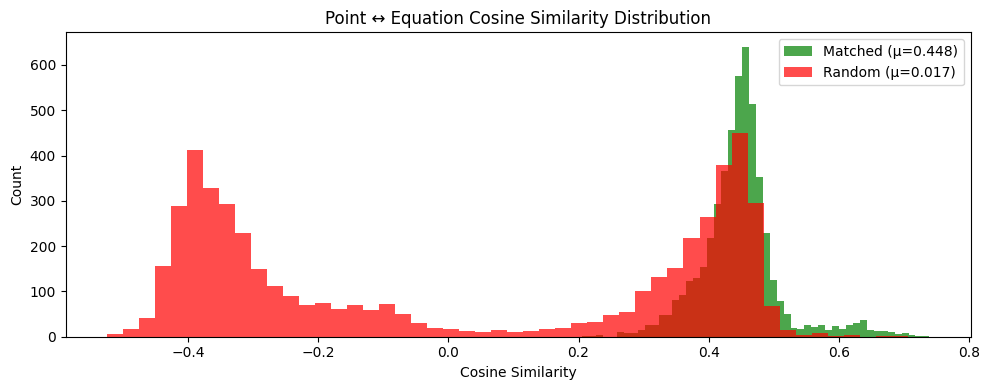

  Saved: cosine_distribution.png

  t-SNE VISUALIZATION
  Running t-SNE on 2000 embeddings...


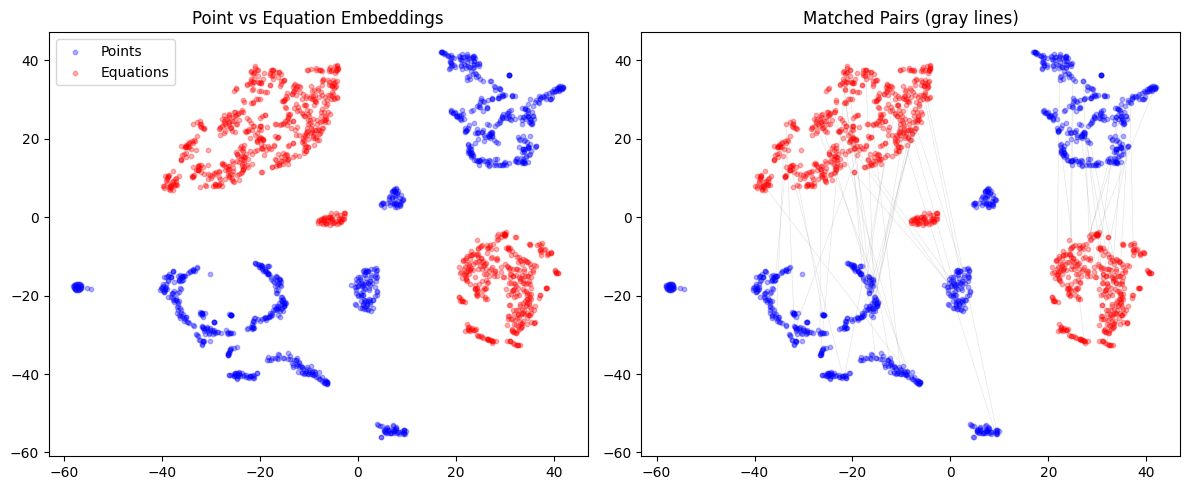

  Saved: tsne_embeddings.png

  NEAREST NEIGHBOR EQUATIONS

  Data points from: ADD SUB x1 POW x2 x1 MUL SUB 1 x2 MUL 1 0.5
  Nearest equations by embedding similarity:
    1. sim=0.485  DIV sqrt ADD POW x3 x2 pi ADD log 2 x2  
    2. sim=0.484  DIV ADD SUB 2 8 DIV 1/3 x2 SUB SUB 3 1 MUL x2 x3  
    3. sim=0.483  DIV SUB 2 x3 ADD DIV 3 pi POW x2 3  
    4. sim=0.482  DIV ADD x3 exp x3 exp MUL NEG 1.5 x2  
    5. sim=0.480  DIV tanh MUL exp x3 log x2 DIV e 2  

  Data points from: POW SUB 0.5 cos x1 e
  Nearest equations by embedding similarity:
    1. sim=0.526  sin ADD sqrt x1 DIV 2 arctan 4  
    2. sim=0.524  sin SUB MUL MUL pi x1 1/4 0.1  
    3. sim=0.524  cos MUL MUL x1 ADD 0.5 2 6  
    4. sim=0.522  cos MUL MUL x1 3 MUL sqrt 1/4 sqrt 1  
    5. sim=0.520  cos ADD MUL x1 SUB 2 4 3  

  Data points from: ADD MUL e cos 2 MUL MUL 4 x2 POW e x1
  Nearest equations by embedding similarity:
    1. sim=0.504  MUL MUL POW x1 x3 x1 1  
    2. sim=0.496  log ADD cos x1 DIV ADD pi x3 ADD e

In [9]:
"""
Test & Evaluate Cross-Modal JEPA
=================================
Loads jepa_phase2.pt and runs:
  1. Retrieval test: given data points, find the correct equation in a batch
  2. Cosine similarity distribution (how well points match their equations)
  3. t-SNE visualization of point vs equation embeddings
  4. Nearest neighbor: show similar equations by point embedding
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from sklearn.manifold import TSNE

# ==========================================
# 1. COPY MODEL DEFINITIONS (same as training)
# ==========================================

MAX_SEQ_LEN = 40

class PointEncoder(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, latent_dim=128, K=8, n_heads=4):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, latent_dim), nn.LayerNorm(latent_dim))
        self.queries = nn.Parameter(torch.randn(1, K, latent_dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(latent_dim, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(latent_dim)
        self.norm2 = nn.LayerNorm(latent_dim)
        self.ffn = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2), nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim))

    def forward(self, x, mask=None):
        h = self.phi(x)
        q = self.queries.expand(x.size(0), -1, -1)
        kp = ~mask if mask is not None else None
        q = q + self.cross_attn(self.norm1(q), h, h, key_padding_mask=kp)[0]
        q = q + self.ffn(self.norm2(q))
        return q


class EqHead(nn.Module):
    def __init__(self, backbone_dim=256, latent_dim=128, K=8, n_heads=4):
        super().__init__()
        self.proj = nn.Linear(backbone_dim, latent_dim)
        self.queries = nn.Parameter(torch.randn(1, K, latent_dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(latent_dim, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(latent_dim)
        self.norm2 = nn.LayerNorm(latent_dim)
        self.ffn = nn.Sequential(
            nn.Linear(latent_dim, latent_dim * 2), nn.GELU(),
            nn.Linear(latent_dim * 2, latent_dim))

    def forward(self, backbone_feats, mask=None):
        h = self.proj(backbone_feats)
        B = h.size(0)
        q = self.queries.expand(B, -1, -1)
        kp = ~mask if mask is not None else None
        q = q + self.cross_attn(self.norm1(q), h, h, key_padding_mask=kp)[0]
        q = q + self.ffn(self.norm2(q))
        return q


class ProjectionHead(nn.Module):
    def __init__(self, latent_dim=128, proj_dim=256, K=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim * K, proj_dim),
            nn.LayerNorm(proj_dim), nn.GELU(),
            nn.Linear(proj_dim, proj_dim))

    def forward(self, z):
        B = z.size(0)
        return F.normalize(self.net(z.reshape(B, -1)), dim=-1)


class EquationTransformer(nn.Module):
    def __init__(self, vocab_size, max_len=40, d_model=256,
                 n_layers=4, n_heads=8, d_ff=512, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.embed_norm = nn.LayerNorm(d_model)
        self.embed_drop = nn.Dropout(dropout)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_ff, dropout=dropout,
                activation="gelu", batch_first=True, norm_first=True),
            num_layers=n_layers)

    def forward(self, token_ids, mask=None):
        B, L = token_ids.shape
        pos = torch.arange(L, device=token_ids.device).unsqueeze(0)
        h = self.token_embed(token_ids) + self.pos_embed(pos)
        h = self.embed_drop(self.embed_norm(h))
        kp = ~mask if mask is not None else None
        return self.transformer(h, src_key_padding_mask=kp)


# ==========================================
# 2. LOAD MODELS
# ==========================================

def load_models(phase2_path, mlm_path, device="cuda"):
    """Load all trained models from checkpoints."""
    print(f"Loading Phase 2 checkpoint: {phase2_path}")
    ckpt = torch.load(phase2_path, map_location=device)
    vocab = ckpt["vocab"]
    K = ckpt.get("K", 8)

    # point encoder
    point_enc = PointEncoder(K=K).to(device)
    point_enc.load_state_dict(ckpt["point_encoder"])
    point_enc.eval()

    # eq head
    eq_head = EqHead(backbone_dim=256, K=K).to(device)
    eq_head.load_state_dict(ckpt["eq_head_ema"])
    eq_head.eval()

    # projection heads
    proj_pts = ProjectionHead(128, 256, K).to(device)
    proj_pts.load_state_dict(ckpt["proj_pts"])
    proj_pts.eval()

    proj_eq = ProjectionHead(128, 256, K).to(device)
    proj_eq.load_state_dict(ckpt["proj_eq"])
    proj_eq.eval()

    # backbone (from MLM checkpoint)
    print(f"Loading MLM backbone: {mlm_path}")
    mlm_ckpt = torch.load(mlm_path, map_location=device)
    backbone = EquationTransformer(
        vocab_size=len(vocab),
        max_len=mlm_ckpt.get("max_len", 40),
        d_model=mlm_ckpt.get("d_model", 256),
        n_layers=mlm_ckpt.get("n_layers", 4),
        n_heads=mlm_ckpt.get("n_heads", 8),
        d_ff=mlm_ckpt.get("d_ff", 512),
    ).to(device)
    state = {k: v for k, v in mlm_ckpt["model_state"].items() if not k.startswith("mlm_head")}
    backbone.load_state_dict(state, strict=False)
    backbone.eval()

    print(f"  Loaded all models (K={K}, vocab={len(vocab)})")
    return point_enc, eq_head, proj_pts, proj_eq, backbone, vocab, K


# ==========================================
# 3. PREPARE TEST DATA
# ==========================================

def prepare_test_data(npz_path, csv_path, vocab, expr_col="expression_prefix_masked",
                      max_equations=5000, device="cuda"):
    """Load a subset of equations for testing."""
    print(f"\nPreparing test data...")
    data = np.load(npz_path)
    df = pd.read_csv(csv_path)

    points_list = []
    lengths_list = []
    token_ids_list = []
    token_lens_list = []
    expressions = []
    valid_indices = []

    for i in tqdm(range(min(len(df), 50000)), desc="Loading"):
        try:
            if f"X_{i}" not in data or data[f"X_{i}"].shape[0] == 0: continue
            x_pts = np.array(data[f"X_{i}"], dtype=np.float32)
            y_pts = np.array(data[f"y_{i}"], dtype=np.float32).ravel()
            if x_pts.ndim == 1: x_pts = x_pts.reshape(-1, 1)
            n_p = min(x_pts.shape[0], len(y_pts), 200)
            n_v = min(x_pts.shape[1], 3)
            if n_p < 4: continue
            x, y = x_pts[:n_p, :n_v].copy(), y_pts[:n_p].copy()
            ok = np.isfinite(x).all(1) & np.isfinite(y)
            x, y = x[ok], y[ok]
            if len(y) < 4: continue
            for c in range(n_v):
                s = x[:, c].std() + 1e-8
                x[:, c] = (x[:, c] - x[:, c].mean()) / s
            ys = y.std() + 1e-8
            if ys < 1e-12: continue
            y = (y - y.mean()) / ys
            x, y = np.clip(x, -10, 10), np.clip(y, -10, 10)
            n_p = len(y)

            expr = df.iloc[i].get(expr_col, "")
            if not isinstance(expr, str) or len(expr.strip().split()) < 2: continue
            ids = [vocab.get(t, vocab.get("[UNK]", 1)) for t in expr.strip().split()]
            if len(ids) < 2: continue

            pts = np.zeros((200, 4), dtype=np.float32)
            pts[:n_p, :n_v] = x
            pts[:n_p, 3] = y
            points_list.append(pts)
            lengths_list.append(n_p)

            tok = np.zeros(MAX_SEQ_LEN, dtype=np.int64)
            sl = min(len(ids), MAX_SEQ_LEN)
            tok[:sl] = ids[:sl]
            token_ids_list.append(tok)
            token_lens_list.append(sl)

            orig_expr = df.iloc[i].get("expression_prefix", expr)
            expressions.append(str(orig_expr))
            valid_indices.append(i)

            if len(points_list) >= max_equations: break
        except: continue

    points = torch.from_numpy(np.stack(points_list))
    lengths = torch.tensor(lengths_list)
    token_ids = torch.from_numpy(np.stack(token_ids_list))
    token_lens = torch.tensor(token_lens_list)

    print(f"  Loaded {len(points)} test equations")
    return points, lengths, token_ids, token_lens, expressions, valid_indices


# ==========================================
# 4. EXTRACT EMBEDDINGS
# ==========================================

@torch.no_grad()
def extract_embeddings(point_enc, eq_head, proj_pts, proj_eq, backbone,
                       points, lengths, token_ids, token_lens,
                       device="cuda", batch_size=256):
    """Extract projected embeddings for all equations."""
    print("\nExtracting embeddings...")
    N = len(points)
    pt_embeds = []
    eq_embeds = []
    pt_kvecs = []
    eq_kvecs = []

    for start in tqdm(range(0, N, batch_size), desc="Batches"):
        end = min(start + batch_size, N)

        pts = points[start:end].to(device)
        lens = lengths[start:end]
        tids = token_ids[start:end].to(device)
        tlens = token_lens[start:end]

        # masks
        pts_mask = torch.zeros(pts.size(0), 200, dtype=torch.bool, device=device)
        tok_mask = torch.zeros(tids.size(0), MAX_SEQ_LEN, dtype=torch.bool, device=device)
        for j in range(end - start):
            pts_mask[j, :lens[j]] = True
            tok_mask[j, :tlens[j]] = True

        # point encoder
        z_pts_k = point_enc(pts, pts_mask)           # (B, K, 128)
        z_pts_proj = proj_pts(z_pts_k)               # (B, 256)

        # equation encoder (backbone + head)
        bb_feats = backbone(tids, tok_mask)           # (B, L, 256)
        z_eq_k = eq_head(bb_feats, tok_mask)          # (B, K, 128)
        z_eq_proj = proj_eq(z_eq_k)                   # (B, 256)

        pt_embeds.append(z_pts_proj.cpu())
        eq_embeds.append(z_eq_proj.cpu())
        pt_kvecs.append(z_pts_k.cpu())
        eq_kvecs.append(z_eq_k.cpu())

    pt_embeds = torch.cat(pt_embeds)    # (N, 256)
    eq_embeds = torch.cat(eq_embeds)    # (N, 256)
    pt_kvecs = torch.cat(pt_kvecs)      # (N, K, 128)
    eq_kvecs = torch.cat(eq_kvecs)      # (N, K, 128)

    print(f"  Point embeddings: {pt_embeds.shape}")
    print(f"  Equation embeddings: {eq_embeds.shape}")
    return pt_embeds, eq_embeds, pt_kvecs, eq_kvecs


# ==========================================
# 5. TESTS
# ==========================================

def test_retrieval(pt_embeds, eq_embeds, expressions, top_k=5):
    """
    For each equation's data points, rank all equations by similarity.
    Report Recall@1, Recall@5, Recall@10.
    """
    print("\n" + "=" * 60)
    print("  RETRIEVAL TEST")
    print("=" * 60)

    N = len(pt_embeds)
    sim_matrix = torch.mm(pt_embeds, eq_embeds.t())  # (N, N)

    # for each row, find rank of correct match (diagonal)
    ranks = []
    for i in range(N):
        sims = sim_matrix[i]
        rank = (sims > sims[i]).sum().item() + 1  # 1-indexed rank
        ranks.append(rank)

    ranks = np.array(ranks)
    r1  = (ranks == 1).mean() * 100
    r5  = (ranks <= 5).mean() * 100
    r10 = (ranks <= 10).mean() * 100
    r50 = (ranks <= 50).mean() * 100
    median_rank = np.median(ranks)
    mean_rank = np.mean(ranks)

    print(f"  Recall@1:   {r1:.1f}%")
    print(f"  Recall@5:   {r5:.1f}%")
    print(f"  Recall@10:  {r10:.1f}%")
    print(f"  Recall@50:  {r50:.1f}%")
    print(f"  Median rank: {median_rank:.0f} / {N}")
    print(f"  Mean rank:   {mean_rank:.0f} / {N}")

    # show some examples
    print(f"\n  Examples (top {top_k} retrieved equations for first 5 queries):")
    for i in range(min(5, N)):
        print(f"\n  Query (data points from): {expressions[i][:80]}")
        top_idx = sim_matrix[i].argsort(descending=True)[:top_k]
        for rank, j in enumerate(top_idx):
            match = "✓" if j == i else " "
            print(f"    {rank+1}. [{match}] sim={sim_matrix[i][j]:.3f}  {expressions[j][:80]}")

    return {"R@1": r1, "R@5": r5, "R@10": r10, "R@50": r50,
            "median_rank": median_rank, "mean_rank": mean_rank}


def test_cosine_distribution(pt_embeds, eq_embeds):
    """Cosine similarity distribution between matched and random pairs."""
    print("\n" + "=" * 60)
    print("  COSINE SIMILARITY DISTRIBUTION")
    print("=" * 60)

    # matched pairs (diagonal)
    matched_cos = F.cosine_similarity(pt_embeds, eq_embeds, dim=-1).numpy()

    # random pairs
    perm = torch.randperm(len(eq_embeds))
    random_cos = F.cosine_similarity(pt_embeds, eq_embeds[perm], dim=-1).numpy()

    print(f"  Matched pairs:  mean={matched_cos.mean():.3f} ± {matched_cos.std():.3f}")
    print(f"  Random pairs:   mean={random_cos.mean():.3f} ± {random_cos.std():.3f}")
    print(f"  Separation:     {matched_cos.mean() - random_cos.mean():.3f}")

    # plot
    plt.figure(figsize=(10, 4))
    plt.hist(matched_cos, bins=50, alpha=0.7, label=f"Matched (μ={matched_cos.mean():.3f})", color="green")
    plt.hist(random_cos, bins=50, alpha=0.7, label=f"Random (μ={random_cos.mean():.3f})", color="red")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Count")
    plt.title("Point ↔ Equation Cosine Similarity Distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig("cosine_distribution.png", dpi=150)
    plt.show()
    print("  Saved: cosine_distribution.png")

    return {"matched_mean": matched_cos.mean(), "random_mean": random_cos.mean()}


def test_tsne(pt_embeds, eq_embeds, expressions, n_samples=1000):
    """t-SNE visualization: point embeddings vs equation embeddings."""
    print("\n" + "=" * 60)
    print("  t-SNE VISUALIZATION")
    print("=" * 60)

    n = min(n_samples, len(pt_embeds))
    idx = np.random.choice(len(pt_embeds), n, replace=False)

    # combine point and equation embeddings
    combined = torch.cat([pt_embeds[idx], eq_embeds[idx]]).numpy()
    labels = ["point"] * n + ["equation"] * n

    print(f"  Running t-SNE on {n*2} embeddings...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(combined)

    pt_coords = coords[:n]
    eq_coords = coords[n:]

    plt.figure(figsize=(12, 5))

    # plot 1: colored by modality
    plt.subplot(1, 2, 1)
    plt.scatter(pt_coords[:, 0], pt_coords[:, 1], c="blue", alpha=0.3, s=10, label="Points")
    plt.scatter(eq_coords[:, 0], eq_coords[:, 1], c="red", alpha=0.3, s=10, label="Equations")
    plt.title("Point vs Equation Embeddings")
    plt.legend()

    # plot 2: lines connecting matched pairs
    plt.subplot(1, 2, 2)
    plt.scatter(pt_coords[:, 0], pt_coords[:, 1], c="blue", alpha=0.3, s=10)
    plt.scatter(eq_coords[:, 0], eq_coords[:, 1], c="red", alpha=0.3, s=10)
    # draw lines for first 50 pairs
    for i in range(min(50, n)):
        plt.plot([pt_coords[i, 0], eq_coords[i, 0]],
                 [pt_coords[i, 1], eq_coords[i, 1]],
                 c="gray", alpha=0.2, linewidth=0.5)
    plt.title("Matched Pairs (gray lines)")

    plt.tight_layout()
    plt.savefig("tsne_embeddings.png", dpi=150)
    plt.show()
    print("  Saved: tsne_embeddings.png")


def test_nearest_neighbors(pt_embeds, eq_embeds, expressions, n_queries=10, top_k=5):
    """For each query's points, show nearest equation embeddings."""
    print("\n" + "=" * 60)
    print("  NEAREST NEIGHBOR EQUATIONS")
    print("=" * 60)

    sim = torch.mm(pt_embeds, eq_embeds.t())

    for i in range(min(n_queries, len(expressions))):
        top_idx = sim[i].argsort(descending=True)[:top_k]
        print(f"\n  Data points from: {expressions[i][:100]}")
        print(f"  Nearest equations by embedding similarity:")
        for rank, j in enumerate(top_idx):
            match = "✓ CORRECT" if j == i else ""
            print(f"    {rank+1}. sim={sim[i][j]:.3f}  {expressions[j][:100]}  {match}")


# ==========================================
# 6. RUN ALL TESTS
# ==========================================

def run_all_tests(
    phase2_path="/content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/jepa_phase2.pt",
    mlm_path="/content/drive/MyDrive/Colab Notebooks/18march 50k data/MLM_DEEpsets_model_files/equation_encoder_mlm.pt",
    npz_path="/content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_data.npz",
    csv_path="/content/drive/MyDrive/Colab Notebooks/18march 50k data/Copy of equations_50k_final_input_18march.csv",
    expr_col="expression_prefix_masked",
    max_test=5000,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # load models
    point_enc, eq_head, proj_pts, proj_eq, backbone, vocab, K = \
        load_models(phase2_path, mlm_path, device)

    # prepare data
    points, lengths, token_ids, token_lens, expressions, indices = \
        prepare_test_data(npz_path, csv_path, vocab, expr_col, max_test, device)

    # extract embeddings
    pt_embeds, eq_embeds, pt_kvecs, eq_kvecs = \
        extract_embeddings(point_enc, eq_head, proj_pts, proj_eq, backbone,
                           points, lengths, token_ids, token_lens, device)

    # run tests
    retrieval = test_retrieval(pt_embeds, eq_embeds, expressions)
    cosine = test_cosine_distribution(pt_embeds, eq_embeds)
    test_tsne(pt_embeds, eq_embeds, expressions)
    test_nearest_neighbors(pt_embeds, eq_embeds, expressions)

    # summary
    print("\n" + "=" * 60)
    print("  SUMMARY")
    print("=" * 60)
    print(f"  Retrieval R@1:  {retrieval['R@1']:.1f}%")
    print(f"  Retrieval R@5:  {retrieval['R@5']:.1f}%")
    print(f"  Retrieval R@10: {retrieval['R@10']:.1f}%")
    print(f"  Matched cosine: {cosine['matched_mean']:.3f}")
    print(f"  Random cosine:  {cosine['random_mean']:.3f}")
    print(f"  Separation:     {cosine['matched_mean'] - cosine['random_mean']:.3f}")


# --- RUN ---
run_all_tests(
    max_test=5000,
)